#Week 8

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir("/content/drive/MyDrive/AI ML 2026/FruitinAmazon/test")

['cupuacu', 'acai', 'pupunha', 'graviola', 'tucuma', 'guarana']

In [1]:
pip install keras tensorflow

In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

#Data Loading and Preprocessing

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Transfer Learning data generators (MobileNetV2 needs [-1,1] range)
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # scales to [-1, 1]
    validation_split=0.2
)

train_data = tl_train_datagen.flow_from_directory(
    "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = tl_train_datagen.flow_from_directory(
    "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

tl_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_data = tl_test_datagen.flow_from_directory(
    "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Scratch model data generators (simple [0,1] rescaling is fine)
scratch_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

scratch_train_data = scratch_datagen.flow_from_directory(
    "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

scratch_val_data = scratch_datagen.flow_from_directory(
    "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

scratch_test_datagen = ImageDataGenerator(rescale=1./255)

scratch_test_data = scratch_test_datagen.flow_from_directory(
    "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Classes: {train_data.class_indices}")
print(f"Num classes: {train_data.num_classes}")

Found 72 images belonging to 6 classes.
Found 18 images belonging to 6 classes.
Found 30 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 18 images belonging to 6 classes.
Found 30 images belonging to 6 classes.
Classes: {'acai': 0, 'cupuacu': 1, 'graviola': 2, 'guarana': 3, 'pupunha': 4, 'tucuma': 5}
Num classes: 6


#Transfer learnign with MobileNetV2

In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load MobileNetV2 base (exclude top classification layers)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ALL base layers
base_model.trainable = False
print(f"Base model layers: {len(base_model.layers)}")
print(f"Trainable layers : {sum(1 for l in base_model.layers if l.trainable)}")

# Add custom classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

tl_model = models.Model(inputs=base_model.input, outputs=output)
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers: 154
Trainable layers : 0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_tl_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print('\n Training Transfer Learning Model ')
tl_history = tl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=tl_callbacks
)


========== Training Transfer Learning Model ==========
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 10s/step - accuracy: 0.2778 - loss: 2.1867 - val_accuracy: 0.3889 - val_loss: 1.5734
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3194 - loss: 1.7774 - val_accuracy: 0.5000 - val_loss: 1.1967
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5556 - loss: 1.1124 - val_accuracy: 0.6111 - val_loss: 0.8625
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.8333 - loss: 0.5437 - val_accuracy: 0.8333 - val_loss: 0.6514
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.9028 - loss: 0.4101 - val_accuracy: 0.8889 - val_loss: 0.4682
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9444 - loss: 0.3356 - val_accuracy: 0.9444 - val_loss: 0.3795
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9861 - loss: 0.2055 - val_accuracy: 0.9444 - val_loss: 0.3371
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9444 - loss: 0.2253 

In [7]:
print('\n Transfer Learning Model — Test Evaluation')
tl_loss, tl_acc = tl_model.evaluate(test_data, verbose=1)
print(f'Test Loss:     {tl_loss:.4f}')
print(f'Test Accuracy: {tl_acc:.4f}')


 Transfer Learning Model — Test Evaluation
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9000 - loss: 0.5333
Test Loss:     0.5333
Test Accuracy: 0.9000


In [8]:
from sklearn.metrics import classification_report
import numpy as np

# Reset generator to ensure predictions align with true labels
test_data.reset()

tl_preds = tl_model.predict(test_data, verbose=1)
tl_y_pred = np.argmax(tl_preds, axis=1)

print('\n=== Classification Report: Transfer Learning (MobileNetV2) ===')
print(classification_report(
    test_data.classes,
    tl_y_pred,
    target_names=list(test_data.class_indices.keys())
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

=== Classification Report: Transfer Learning (MobileNetV2) ===
              precision    recall  f1-score   support

        acai       1.00      1.00      1.00         5
     cupuacu       1.00      1.00      1.00         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      1.00      1.00         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.67      0.80      0.73         5

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [9]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

img_path = "/content/drive/MyDrive/AI ML 2026/FruitinAmazon/train/pupunha/images (1).jpeg"

img       = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)          # shape: (224, 224, 3)
img_array = preprocess_input(img_array)       # scale to [-1, 1] for MobileNetV2
img_array = np.expand_dims(img_array, axis=0) # shape: (1, 224, 224, 3)

tl_pred       = tl_model.predict(img_array, verbose=0)
tl_pred_class = list(train_data.class_indices.keys())[np.argmax(tl_pred)]
tl_confidence = np.max(tl_pred) * 100

print(f'[Transfer Learning] Predicted class : {tl_pred_class}')
print(f'[Transfer Learning] Confidence      : {tl_confidence:.2f}%')

[Transfer Learning] Predicted class : pupunha
[Transfer Learning] Confidence      : 54.06%


#Scratch CNN MOdel (for comparison)

In [10]:
from tensorflow.keras import Sequential
from tensorflow.keras import layers

scratch_model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
], name='Scratch_CNN')

scratch_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

scratch_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_scratch_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print('Training Scratch CNN Mode')
scratch_history = scratch_model.fit(
    scratch_train_data,
    validation_data=scratch_val_data,
    epochs=10,
    callbacks=scratch_callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



========== Training Scratch CNN Model ==========
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.2222 - loss: 14.9296 - val_accuracy: 0.0556 - val_loss: 15.0597
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.1944 - loss: 11.6114 - val_accuracy: 0.2778 - val_loss: 3.0949
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.3194 - loss: 2.3396 - val_accuracy: 0.3333 - val_loss: 1.8749
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.6250 - loss: 1.2411 - val_accuracy: 0.3333 - val_loss: 1.5549
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step - accuracy: 0.7222 - loss: 0.9519 - val_accuracy: 0.4444 - val_loss: 1.7303
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8611 - loss: 0.6795 - val_accuracy: 0.3333 - val_loss: 1.6395
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.9583 - loss: 0.3640 - val_accuracy: 0.5556 - val_loss: 1.4326
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.9583 - loss: 0.2413 

In [11]:
scratch_test_data.reset()

scratch_preds  = scratch_model.predict(scratch_test_data, verbose=1)
scratch_y_pred = np.argmax(scratch_preds, axis=1)

sc_loss, sc_acc = scratch_model.evaluate(scratch_test_data, verbose=0)
print(f'Scratch Model — Test Loss: {sc_loss:.4f}  Test Accuracy: {sc_acc:.4f}')

print('\n=== Classification Report: Scratch CNN ===')
print(classification_report(
    scratch_test_data.classes,
    scratch_y_pred,
    target_names=list(scratch_test_data.class_indices.keys())
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step
Scratch Model — Test Loss: 0.9507  Test Accuracy: 0.6000

=== Classification Report: Scratch CNN ===
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.38      1.00      0.56         5
     guarana       0.67      0.80      0.73         5
     pupunha       0.75      0.60      0.67         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.60        30
   macro avg       0.60      0.60      0.55        30
weighted avg       0.60      0.60      0.55        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
img       = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0   # [0, 1] scaling for scratch model
img_array = np.expand_dims(img_array, axis=0)

sc_pred       = scratch_model.predict(img_array, verbose=0)
sc_pred_class = list(train_data.class_indices.keys())[np.argmax(sc_pred)]
sc_confidence = np.max(sc_pred) * 100

print(f'[Scratch CNN] Predicted class : {sc_pred_class}')
print(f'[Scratch CNN] Confidence      : {sc_confidence:.2f}%')

[Scratch CNN] Predicted class : guarana
[Scratch CNN] Confidence      : 75.98%


##Training curves: Transfer Learning vs Scratch

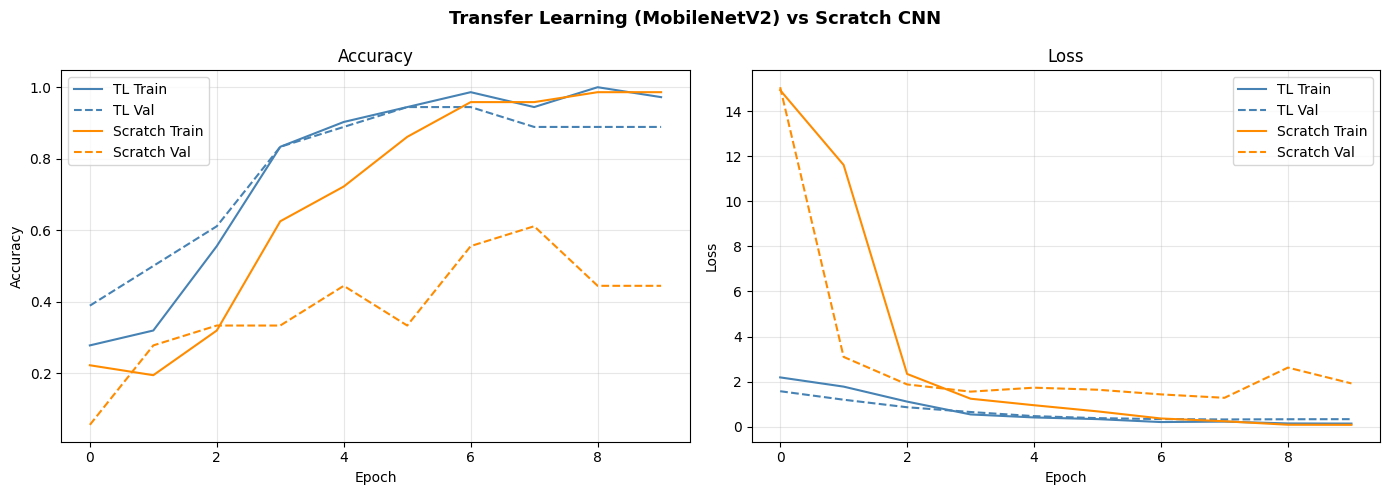

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transfer Learning (MobileNetV2) vs Scratch CNN', fontsize=13, fontweight='bold')

# Accuracy
axes[0].plot(tl_history.history['accuracy'],     label='TL Train',     color='steelblue')
axes[0].plot(tl_history.history['val_accuracy'], label='TL Val',       color='steelblue', linestyle='--')
axes[0].plot(scratch_history.history['accuracy'],     label='Scratch Train', color='darkorange')
axes[0].plot(scratch_history.history['val_accuracy'], label='Scratch Val',   color='darkorange', linestyle='--')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(tl_history.history['loss'],     label='TL Train',     color='steelblue')
axes[1].plot(tl_history.history['val_loss'], label='TL Val',       color='steelblue', linestyle='--')
axes[1].plot(scratch_history.history['loss'],     label='Scratch Train', color='darkorange')
axes[1].plot(scratch_history.history['val_loss'], label='Scratch Val',   color='darkorange', linestyle='--')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Final Performance Comparison

In [14]:
print('=' * 55)
print(f"{'Model':<30} {'Accuracy':>10} {'Loss':>10}")
print('-' * 55)
print(f"{'Transfer Learning (MobileNetV2)':<30} {tl_acc:>10.4f} {tl_loss:>10.4f}")
print(f"{'Scratch CNN':<30} {sc_acc:>10.4f} {sc_loss:>10.4f}")
print('=' * 55)

if tl_acc > sc_acc:
    diff = (tl_acc - sc_acc) * 100
    print(f'Transfer Learning improved accuracy by {diff:.2f}% over Scratch CNN.')
    print('This confirms that pretrained ImageNet features generalise well to the fruit dataset.')
else:
    diff = (sc_acc - tl_acc) * 100
    print(f'Scratch CNN outperformed Transfer Learning by {diff:.2f}%.')
    print('Consider fine-tuning some top base layers or training for more epochs.')

Model                            Accuracy       Loss
-------------------------------------------------------
Transfer Learning (MobileNetV2)     0.9000     0.5333
Scratch CNN                        0.6000     0.9507
Transfer Learning improved accuracy by 30.00% over Scratch CNN.
This confirms that pretrained ImageNet features generalise well to the fruit dataset.
